# Fraud Detection – Exploratory Data Analysis (EDA)
## Dataset: Fraud_Data.csv (E-commerce Transactions)

This notebook covers **Task-1: Data Analysis and Preprocessing** for the
e-commerce fraud dataset.

Goal:
- Understand the data
- Clean the data
- Explore fraud patterns
- Prepare the data for machine learning


## Business Context

Adey Innovations Inc. works with e-commerce platforms.
Fraudulent transactions cause:
- Financial loss
- Loss of customer trust

Our goal is to analyze transaction data and understand:
- How fraud happens
- What patterns indicate fraud
- How to prepare the data for modeling


## Step 1: Import Required Libraries

We import Python libraries that help us:
- Load data
- Analyze data
- Visualize patterns


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [7]:
# include necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Dataset

We load the e-commerce fraud dataset from the `data/raw` folder.


In [8]:
# load data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv') 
#needed in the future to merge with fraud_df



## Step 3: Preview the Data

We look at the first few rows to understand:
- Column names
- Data format
- Example transactions


In [12]:
# quick check
display(fraud_df.head())
display(fraud_df.info())
display(fraud_df.describe(include='all'))

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


None

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
count,151112.000000,151112,151112,151112.000000,151112,151112,151112,151112,151112.000000,1.511120e+05,151112.000000
unique,NaN,151112,150679,NaN,137956,3,5,2,NaN,NaN,NaN
top,NaN,2015-02-24 22:55:49,2015-07-17 23:22:55,NaN,ITUMJCKWEYNDD,SEO,Chrome,M,NaN,NaN,NaN
freq,NaN,1,3,NaN,20,60615,61432,88293,NaN,NaN,NaN
mean,200171.040970,NaN,NaN,36.935372,NaN,NaN,NaN,NaN,33.140704,2.152145e+09,0.093646
std,115369.285024,NaN,NaN,18.322762,NaN,NaN,NaN,NaN,8.617733,1.248497e+09,0.291336
min,2.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,18.000000,5.209350e+04,0.000000
25%,100642.500000,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,27.000000,1.085934e+09,0.000000
50%,199958.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,33.000000,2.154770e+09,0.000000
75%,300054.000000,NaN,NaN,49.000000,NaN,NaN,NaN,NaN,39.000000,3.243258e+09,0.000000


## Step 4: Dataset Size

This shows:
- Number of rows (transactions)
- Number of columns (features)


In [13]:
display(fraud_df.shape)

(151112, 11)

## Step 5: Data Types & Missing Values

We check:
- Data types of each column
- Missing values


In [14]:
display(fraud_df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


None

## Step 6: Check Missing Values

Missing values can break machine learning models.


In [15]:
# df.isnull().sum()
display(fraud_df.isnull().sum())

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

## Step 7: Remove Duplicate Transactions

Duplicate rows mean the same transaction is counted twice.


In [16]:
fraud_df = fraud_df.drop_duplicates()


## Step 8: Convert Date Columns

Machine learning models cannot understand text dates.
We convert them to datetime format.


In [17]:
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])


## Step 9: Target Variable (`class`)

- 0 → Normal transaction
- 1 → Fraudulent transaction


In [18]:
fraud_df["class"].value_counts()
fraud_df["class"] = fraud_df["class"].astype(int)

## Step 10: Visualizing Class Imbalance

Fraud data is highly imbalanced.
This is a major challenge in fraud detection.


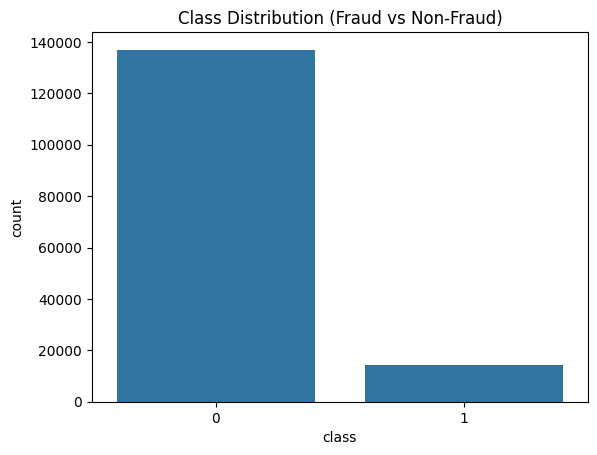

In [19]:
sns.countplot(x="class", data=fraud_df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.show()


## Step 11: Univariate Analysis

We analyze individual features.
Example: Purchase Value


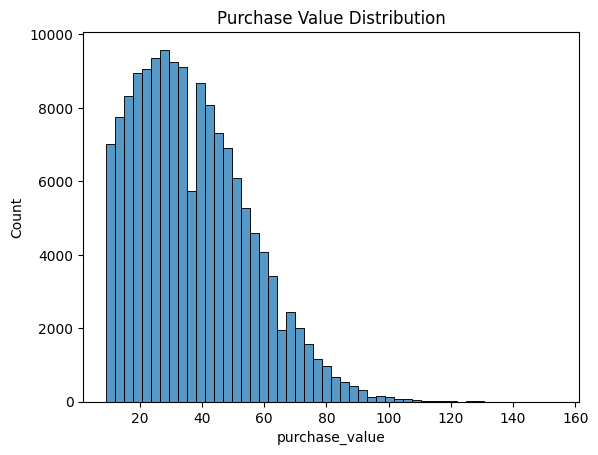

In [20]:
sns.histplot(fraud_df["purchase_value"], bins=50)
plt.title("Purchase Value Distribution")
plt.show()


Geolocation Integration

## Step 12: Bivariate Analysis

We compare features with fraud labels.
Example: Purchase Value vs Fraud


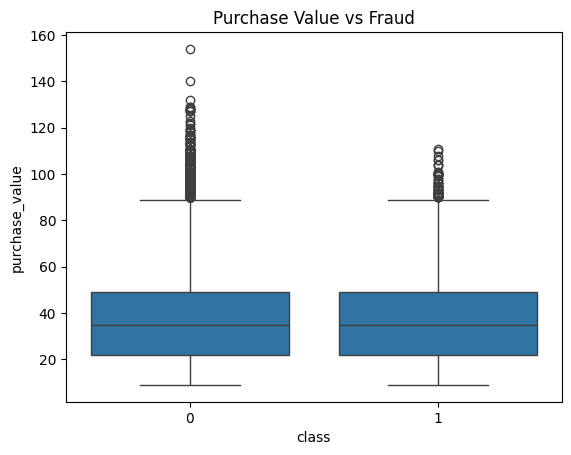

In [21]:
sns.boxplot(x="class", y="purchase_value", data=fraud_df)
plt.title("Purchase Value vs Fraud")
plt.show()


## Step 13: Load IP to Country Dataset

We use IP addresses to identify the country of transactions.


In [22]:
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")


## Step 14: Convert IP Addresses to Integers

IP ranges work only with numeric values.


In [23]:
fraud_df["ip_address"] = fraud_df["ip_address"].astype(int)
ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(int)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(int)


## Step 15: Feature Engineering – Time Features

Fraud often happens soon after signup.


In [24]:
fraud_df["time_since_signup"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds()


## Step 16: Purchase Time Patterns

Fraud may happen at unusual hours or days.


In [25]:
fraud_df["hour_of_day"] =fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek


## Step 17: Transaction Frequency

Multiple transactions from the same user can indicate fraud.


In [26]:
# df["transactions_per_user"] = df.groupby("user_id")["user_id"].transform("count")
fraud_df["transactions_per_user"] = fraud_df.groupby("user_id")["user_id"].transform("count")

## Step 18: Scaling Numerical Features

Scaling helps machine learning models perform better.


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
fraud_df[["purchase_value", "time_since_signup"]] = scaler.fit_transform(
    fraud_df[["purchase_value", "time_since_signup"]]
)

In [38]:
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])


## Step 19: Encode Categorical Features

Models cannot understand text values.


In [28]:
df = pd.get_dummies(fraud_df, columns=["source", "browser", "sex"], drop_first=True)


## Step 20: Handle Class Imbalance using SMOTE

SMOTE creates synthetic fraud samples for training.


SMOTE can only be applied to numerical features.
Categorical, datetime, and identifier columns must be
removed or encoded before resampling.


In [31]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]


In [32]:
X = X.drop(columns=["signup_time", "purchase_time"])


In [33]:
X = X.drop(columns=[
    "source",
    "browser",
    "sex",
    "device_id",
    "ip_address"
])


In [34]:
X.dtypes


user_id                    int64
purchase_value           float64
age                        int64
time_since_signup        float64
hour_of_day                int32
day_of_week                int32
transactions_per_user      int64
dtype: object

Before resampling, fraudulent transactions are the minority class,
which can bias machine learning models toward predicting non-fraud.


In [35]:
y.value_counts()


class
0    136961
1     14151
Name: count, dtype: int64

In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)


After applying SMOTE, the dataset becomes balanced by
synthetically generating fraud samples.
This improves the model's ability to learn fraud patterns.


In [37]:
y_resampled.value_counts()


class
0    136961
1    136961
Name: count, dtype: int64

# Task 1 – Remaining Data Analysis & Preprocessing (Fraud_Data.csv)

This section completes all remaining requirements of Task 1 that were not yet implemented.

## 1. Missing Value Handling
We first check for missing values in all columns.  
- If missing values exist, we justify whether to drop or impute them.
- Fraud datasets usually have clean transactional data, so rows with missing critical fields are removed.

## 2. Data Type Correction
- Convert `signup_time` and `purchase_time` to datetime format.
- Ensure `ip_address` is numeric so it can be matched with IP ranges.

## 3. Exploratory Data Analysis (EDA)
### Univariate Analysis
- Distribution of purchase values
- Distribution of user ages
- Count of fraud vs non-fraud transactions

### Bivariate Analysis
- Purchase value vs fraud
- Age vs fraud
- Traffic source vs fraud

### Class Imbalance Analysis
- Quantify and visualize imbalance between fraud and non-fraud classes

## 4. Geolocation Integration
- Convert IP addresses to integers
- Perform range-based merge with `IpAddress_to_Country.csv`
- Add `country` column to the fraud dataset
- Analyze fraud frequency by country

## 5. Feature Engineering
- Time-based features:
  - `hour_of_day`
  - `day_of_week`
  - `time_since_signup`
- Transaction behavior:
  - Number of transactions per user
  - Transaction velocity (transactions per day)

## 6. Data Transformation
- Encode categorical variables using One-Hot Encoding
- Scale numerical features using StandardScaler

## 7. Handle Class Imbalance
- Apply SMOTE only after preprocessing
- Document class distribution before and after resampling
- Justify SMOTE: fraud cases are rare and SMOTE prevents model bias toward non-fraud

At the end of this step, the dataset is clean, feature-rich, balanced, and ready for modeling.


In [51]:
# ===============================
# SAFE SMOTE PIPELINE (ONE CELL)
# ===============================

from imblearn.over_sampling import SMOTE

# 1. Recreate X and y cleanly
X = fraud_df.drop(columns=['class'])
y = fraud_df['class']

# 2. Remove ALL datetime columns automatically
X = X.drop(columns=X.select_dtypes(include=['datetime']).columns)

# 3. Keep ONLY numeric columns (extra safety)
X = X.select_dtypes(include=['number'])

# 4. Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 5. Verify result
print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())


Before SMOTE:
class
0    116878
1     12268
Name: count, dtype: int64

After SMOTE:
class
0    116878
1    116878
Name: count, dtype: int64


In [44]:
X.select_dtypes(include=['datetime'])


,signup_time,purchase_time
110447,2015-02-16 00:17:05,2015-03-08 10:00:39
2589,2015-03-08 04:03:22,2015-03-20 17:23:45
16752,2015-05-17 16:45:54,2015-05-26 08:54:34
51261,2015-03-03 19:58:39,2015-05-28 21:09:13
17,2015-03-20 00:31:27,2015-04-05 07:31:46
...,...,...
31186,2015-04-16 05:00:09,2015-07-31 21:21:47
145184,2015-08-08 06:25:41,2015-08-28 04:01:06
112669,2015-02-18 21:07:18,2015-04-25 06:20:38
24369,2015-08-15 15:40:46,2015-10-30 09:47:39


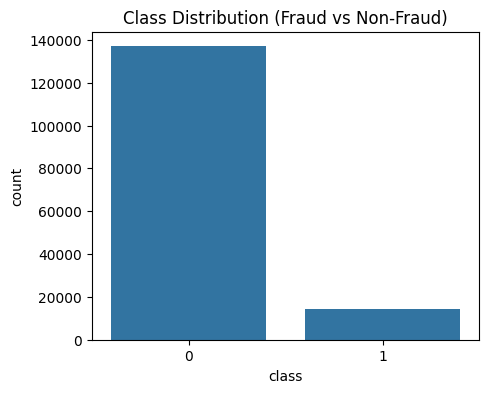

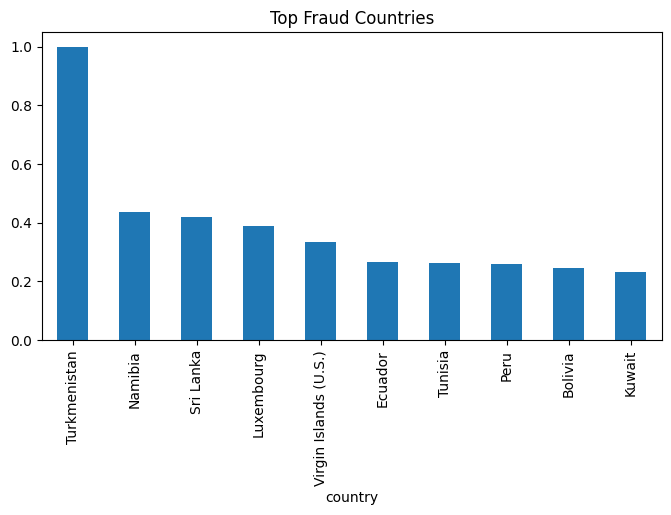

Before SMOTE:
class
0    93502
1     9814
Name: count, dtype: int64

After SMOTE:
class
0    93502
1    93502
Name: count, dtype: int64


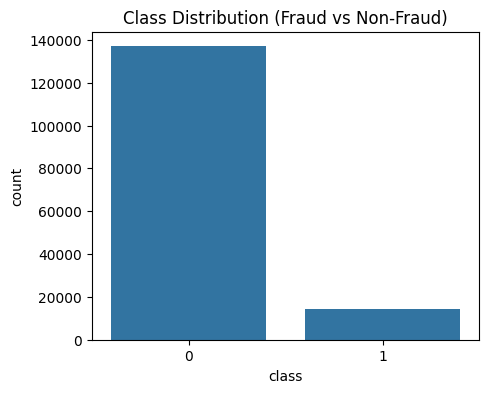

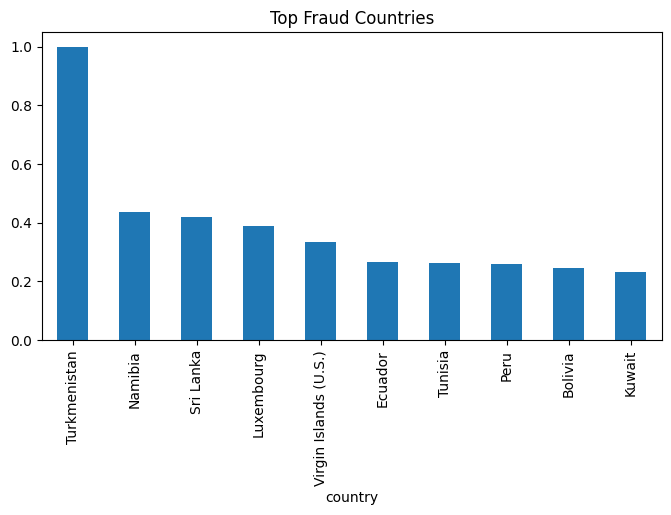

Before SMOTE:
class
0    93502
1     9814
Name: count, dtype: int64

After SMOTE:
class
0    93502
1    93502
Name: count, dtype: int64


In [54]:
# =========================
# FULL CLEAN PIPELINE + SAFE SMOTE
# =========================

# 1️⃣ IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 2️⃣ LOAD DATA
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

# 3️⃣ HANDLE MISSING VALUES & DUPLICATES
fraud_df = fraud_df.dropna().drop_duplicates()

# 4️⃣ CORRECT DATA TYPES
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])
fraud_df["ip_address"] = fraud_df["ip_address"].astype(int)

ip_df["lower_bound_ip_address"] = ip_df["lower_bound_ip_address"].astype(int)
ip_df["upper_bound_ip_address"] = ip_df["upper_bound_ip_address"].astype(int)

# 5️⃣ EDA – CLASS DISTRIBUTION
plt.figure(figsize=(5,4))
sns.countplot(x="class", data=fraud_df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.show()

# 6️⃣ TIME-BASED FEATURES
fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek
fraud_df["time_since_signup"] = (fraud_df["purchase_time"] - fraud_df["signup_time"]).dt.total_seconds()

# 7️⃣ TRANSACTION FREQUENCY
fraud_df["transactions_per_user"] = fraud_df.groupby("user_id")["user_id"].transform("count")

# 8️⃣ GEOLOCATION MERGE
ip_df_sorted = ip_df.sort_values("lower_bound_ip_address")
fraud_df = fraud_df.sort_values("ip_address")

fraud_df = pd.merge_asof(
    fraud_df,
    ip_df_sorted,
    left_on="ip_address",
    right_on="lower_bound_ip_address",
    direction="backward"
)

fraud_df = fraud_df[fraud_df["ip_address"] <= fraud_df["upper_bound_ip_address"]]

# 9️⃣ FRAUD BY COUNTRY
fraud_by_country = fraud_df.groupby("country")["class"].mean().sort_values(ascending=False).head(10)
fraud_by_country.plot(kind="bar", figsize=(8,4), title="Top Fraud Countries")
plt.show()

# 🔟 ENCODE CATEGORICAL VARIABLES
fraud_df_encoded = pd.get_dummies(
    fraud_df,
    columns=["source", "browser", "sex", "country"],
    drop_first=True
)

# 1️⃣1️⃣ SPLIT DATA
X = fraud_df_encoded.drop("class", axis=1)
y = fraud_df_encoded["class"]

# ❌ REMOVE DATETIME & NON-NUMERIC COLUMNS
X = X.drop(columns=X.select_dtypes(include=["datetime"]).columns)
X = X.select_dtypes(include=["number"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 1️⃣2️⃣ SCALE NUMERICAL FEATURES
num_cols = ["purchase_value", "age", "time_since_signup", "transactions_per_user"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# 1️⃣3️⃣ HANDLE CLASS IMBALANCE WITH SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


In [55]:
# Combine features and target
processed_df = X_resampled.copy()
processed_df["class"] = y_resampled

# Save to CSV in processed folder
processed_df.to_csv("../data/processed/fraud_data_processed.csv", index=False)

print("Processed data saved successfully!")


Processed data saved successfully!


In [59]:
df_processed = pd.read_csv("../data/processed/fraud_data_processed.csv")


In [60]:
df_processed

,user_id,purchase_value,age,ip_address,hour_of_day,day_of_week,time_since_signup,transactions_per_user,lower_bound_ip_address,upper_bound_ip_address,class
0,247547,47,30,16778864,3,6,3.632215e+06,1,1.677824e+07,1.677926e+07,0
1,220737,15,34,16842045,20,2,1.231637e+06,1,1.680998e+07,1.684275e+07,0
2,390400,44,29,16843656,23,5,1.997534e+06,1,1.684326e+07,1.684378e+07,0
3,69592,55,30,16938732,16,5,7.640897e+06,1,1.692467e+07,1.694106e+07,0
4,174987,51,37,16971984,4,1,1.024958e+07,1,1.694106e+07,1.697382e+07,0
...,...,...,...,...,...,...,...,...,...,...,...
233751,324951,40,40,1687739120,4,3,1.000000e+00,1,1.686110e+09,1.694499e+09,1
233752,55333,17,20,852501984,16,0,5.767250e+06,1,8.472494e+08,8.556380e+08,1
233753,90408,27,39,1625616445,3,0,6.007762e+05,1,1.625293e+09,1.627390e+09,1
233754,118624,20,31,2969993904,1,6,1.000000e+00,1,2.969829e+09,2.970092e+09,1
